## Lab 4
####Rayan Karki (022BSCIT034)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict

In [2]:
img = cv2.imread('img.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = cv2.resize(img, (256, 256))

In [3]:
def plot(rows, cols, images, titles):
    plt.figure(figsize=(15, 10))
    for i in range(rows):
        for j in range(cols):
            plt.subplot(rows, cols, i * cols + j + 1)
            if type(images[i*cols+j][0]) == np.ndarray:
                plt.imshow(images[i*cols+j], cmap='gray')
            else:
                plt.bar(range(256), images[i*cols+j])
            plt.title(titles[i*cols+j])

#### Noise  

In [4]:
def histogram(img):
    hist = [0 for i in range(256)]
    for i in img:
        for j in i:
            hist[j]+=1
    return hist

In [6]:
def gaussianNoise(image, mean=0, var=20):
    noisy_image = np.copy(image)
    rows, cols = noisy_image.shape
    sigma = var ** 0.5

    for i in range(rows):
        for j in range(cols):
            noise = np.random.normal(mean, sigma)
            new_value = noisy_image[i, j] + noise
            new_value = max(0, min(255, new_value))
            noisy_image[i, j] = new_value
    return noisy_image


In [8]:
def saltAndPepperNoise(image, salt_prob=0.01, pepper_prob=0.01):
    noisy_image = np.copy(image)
    rows, cols = noisy_image.shape
    total_pixels = rows * cols
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)
    for _ in range(num_salt):
        i = np.random.randint(0, rows)
        j = np.random.randint(0, cols)
        noisy_image[i, j] = 255
    for _ in range(num_pepper):
        i = np.random.randint(0, rows)
        j = np.random.randint(0, cols)
        noisy_image[i, j] = 0
    return noisy_image

In [9]:
def uniformNoise(image, low=-40, high=40):
    noisy = image.copy().astype(np.int16)  # To avoid overflow
    noise = np.random.uniform(low, high, image.shape)
    noisy = noisy + noise
    noisy = np.clip(noisy, 0, 255)  # Keep within valid range
    return noisy.astype(np.uint8)

<Figure size 1500x600 with 0 Axes>

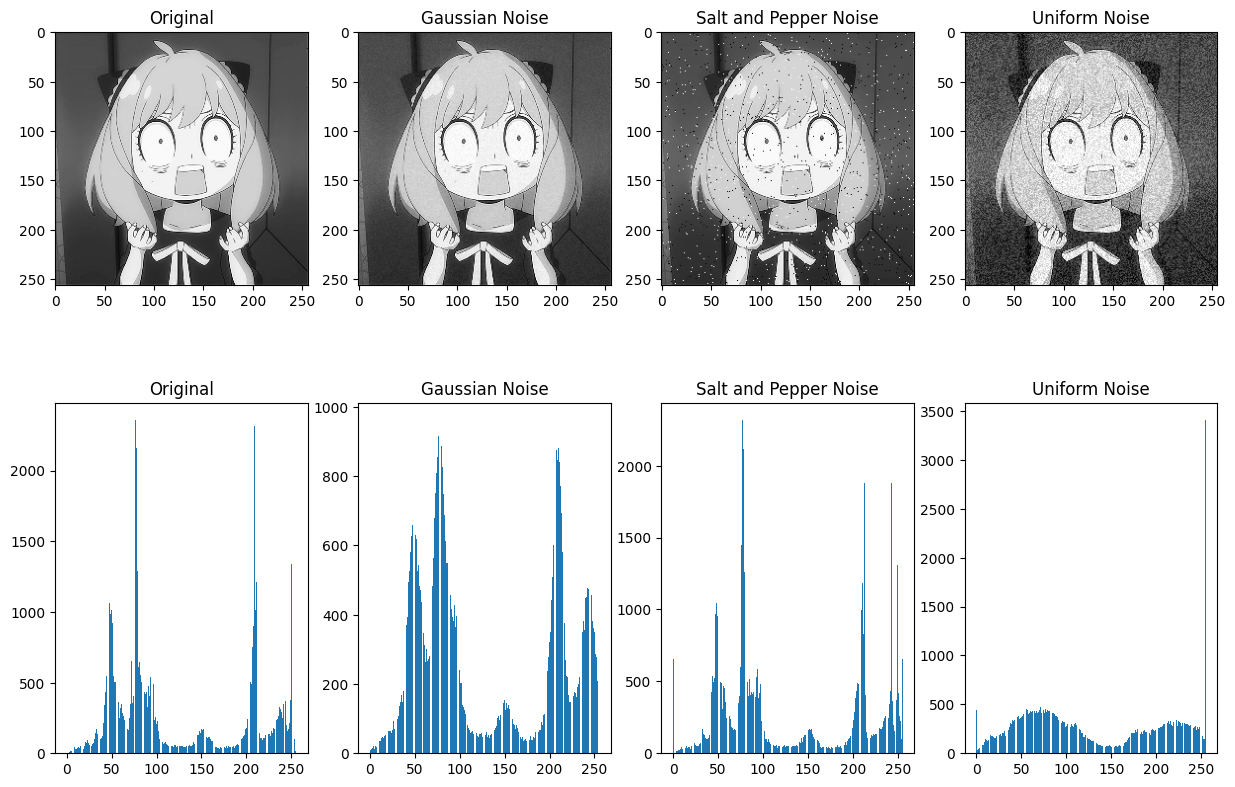

In [10]:
gaussian = gaussianNoise(img, 0, 20)
saltAndPepper = saltAndPepperNoise(img)
uniform = uniformNoise(img)

plt.figure(figsize=(15, 6))
plot(2,4, [
    img, gaussian, saltAndPepper, uniform, 
    histogram(img), histogram(gaussian), histogram(saltAndPepper), histogram(uniform)
], ["Original", "Gaussian Noise", "Salt and Pepper Noise", "Uniform Noise"]*2)

#### Restoration Filter

In [11]:
def averageRestoration(img):
    kernel = np.ones((3,3), dtype=np.uint8)/9
    padImg = np.pad(img, 1)
    output = []
    for i in range(1, len(img)):
        temp = []
        for j in range(1, len(img[0])):
            temp.append(np.sum(padImg[i-1:i+2, j-1:j+2]*kernel))
        output.append(temp)
    return np.array(output)

In [12]:
def minOrderStatistics(img):
    padImg = np.pad(img, 1)
    output = []
    for i in range(1, len(img)):
        temp = []
        for j in range(1, len(img[0])):
            temp.append(np.min(padImg[i-1:i+2, j-1:j+2]))
        output.append(temp)
    return np.array(output)

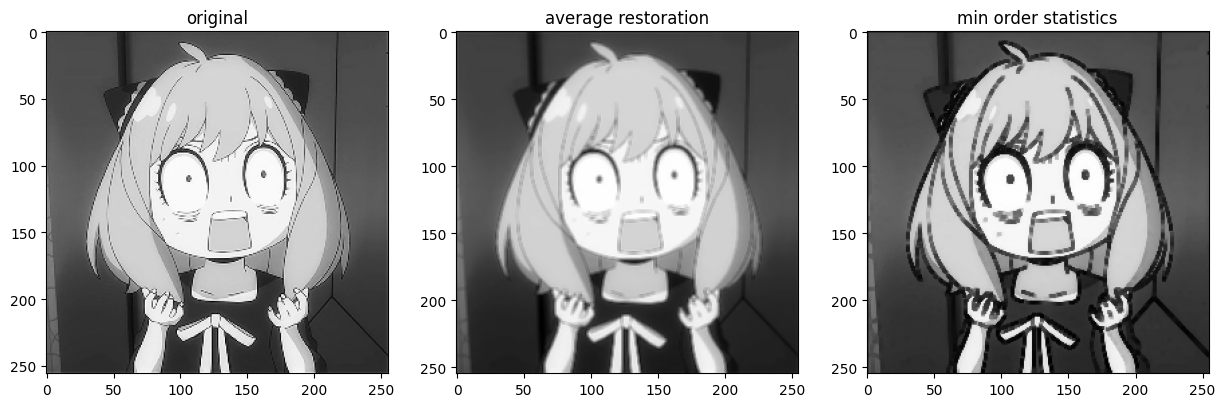

In [13]:
dummy = img
plot(1, 3, [dummy, averageRestoration(dummy), minOrderStatistics(dummy)], ["original", "average restoration", "min order statistics"])

In [14]:
def dft_image(img):
    dft = np.fft.fft2(img)
    dft_shift = np.fft.fftshift(dft)
    return dft_shift

def idft_image(dft_shift):
    f_ishift = np.fft.ifftshift(dft_shift)
    img_back = np.fft.ifft2(f_ishift)
    return np.abs(img_back)

In [16]:
def create_ideal_filter(shape, low_cutoff, high_cutoff, band_type='pass'):
    rows, cols = shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros((rows, cols), np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow)**2 + (v - ccol)**2)
            if band_type == 'pass':
                if low_cutoff <= D <= high_cutoff:
                    mask[u, v] = 1
            elif band_type == 'reject':
                if D < low_cutoff or D > high_cutoff:
                    mask[u, v] = 1
    return mask

In [17]:
def create_butterworth_filter(shape, low_cutoff, high_cutoff, n, band_type='pass'):
    rows, cols = shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros((rows, cols), np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow)**2 + (v - ccol)**2)
            if band_type == 'reject':
                mask[u, v] = 1 / (1 + ((D * (high_cutoff - low_cutoff)) / (D**2 - low_cutoff * high_cutoff))**(2*n))
            elif band_type == 'pass':
                mask[u, v] = 1 - (1 / (1 + ((D * (high_cutoff - low_cutoff)) / (D**2 - low_cutoff * high_cutoff))**(2*n)))
    return mask

In [18]:
def create_gaussian_filter(shape, low_cutoff, high_cutoff, band_type='pass'):
    rows, cols = shape
    crow, ccol = rows // 2 , cols // 2
    mask = np.zeros((rows, cols), np.float32)

    for u in range(rows):
        for v in range(cols):
            D = np.sqrt((u - crow)**2 + (v - ccol)**2)
            if band_type == 'pass':
                mask[u, v] = np.exp(-((D**2 - low_cutoff * high_cutoff)**2) / (D**2 * (high_cutoff - low_cutoff)**2 + 1e-5))
            elif band_type == 'reject':
                mask[u, v] = 1 - np.exp(-((D**2 - low_cutoff * high_cutoff)**2) / (D**2 * (high_cutoff - low_cutoff)**2 + 1e-5))
    return mask

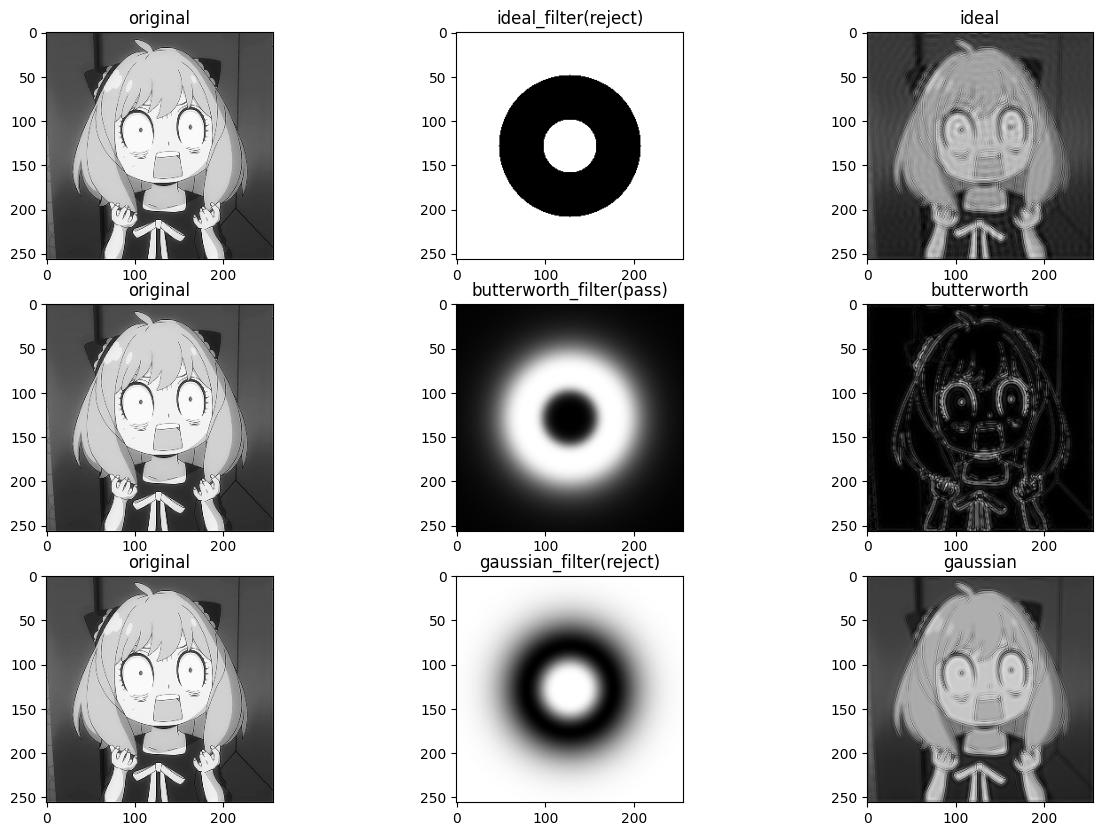

In [19]:
dft = dft_image(img)

# Create a filter (choose one)
ideal_filter = create_ideal_filter(img.shape, 30, 80, band_type='reject')
butterworth_filter = create_butterworth_filter(img.shape, 30, 80, n=2, band_type='pass')
gaussian_filter = create_gaussian_filter(img.shape, 30, 80, band_type='reject')

# Apply filter
filtered_dft = dft * ideal_filter  # change this to the filter you want
filtered_img = idft_image(filtered_dft)

plot(3,3, [img, ideal_filter, idft_image(dft*ideal_filter),
           img, butterworth_filter, idft_image(dft*butterworth_filter),
           img, gaussian_filter, idft_image(dft*gaussian_filter)],
           ['original','ideal_filter(reject)','ideal',
            'original','butterworth_filter(pass)','butterworth',
            'original','gaussian_filter(reject)','gaussian'])

#### Image compression Techniques

In [20]:
class Node:
    def __init__(self, sym, freq, left=None, right=None):
        self.sym, self.freq, self.left, self.right = sym, freq, left, right
    def __lt__(self, other): return self.freq < other.freq

def huffman_encode(img):
    flat = img.flatten()
    freq = defaultdict(int)
    for px in flat: freq[px] += 1

    heap = [Node(sym, f) for sym, f in freq.items()]
    heapq.heapify(heap)
    while len(heap) > 1:
        l, r = heapq.heappop(heap), heapq.heappop(heap)
        heapq.heappush(heap, Node(None, l.freq + r.freq, l, r))
    root = heap[0]

    codes = {}
    def gen_codes(node, code=""):
        if node:
            if node.sym is not None: codes[node.sym] = code
            gen_codes(node.left, code + "0")
            gen_codes(node.right, code + "1")
    gen_codes(root)

    encoded = "".join(codes[p] for p in flat)
    return encoded, codes

In [21]:
encoded_bits, huffman_codes = huffman_encode(img)

encodedLength = len(encoded_bits)
originalLength = img.size * 8

print("Encoded Length:", encodedLength)
print("Original Length:", originalLength)
print("Compression Ratio:", originalLength / encodedLength)
print("Relative Data Redundancy", (originalLength - encodedLength) / originalLength)

Encoded Length: 465555
Original Length: 524288
Compression Ratio: 1.1261569524545971
Relative Data Redundancy 0.11202430725097656


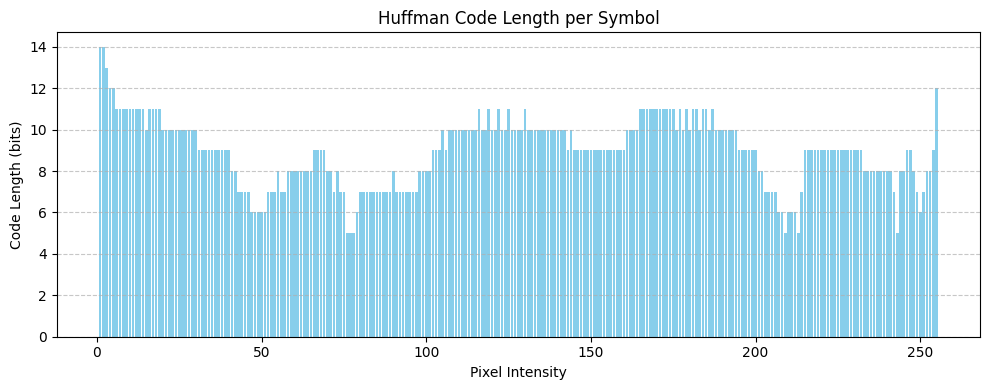

In [22]:

symbols = list(huffman_codes.keys())
code_lengths = [len(huffman_codes[s]) for s in symbols]

plt.figure(figsize=(10, 4))
plt.bar(symbols, code_lengths, color='skyblue')
plt.xlabel("Pixel Intensity")
plt.ylabel("Code Length (bits)")
plt.title("Huffman Code Length per Symbol")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()